# CNNs avec Keras sur des données de paysage

## Vérification de l'utilisation de GPU

Allez dans le menu `Exécution > Modifier le type d'execution` et vérifiez que l'on est bien en Python 3 et que l'accélérateur matériel est configuré sur « GPU ».

In [1]:
!nvidia-smi

Sat Mar 28 11:36:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Téléchargement du dataset Landscape depuis un repo git

In [2]:
!git clone https://github.com/nzmonzmp/dataset-landscape.git
!ls dataset-landscape
print("***")
!ls -l dataset-landscape/seg_train
print("***")
!ls -l dataset-landscape/seg_pred

Cloning into 'dataset-landscape'...
remote: Enumerating objects: 24310, done.
remote: Total 24310 (delta 0), reused 0 (delta 0), pack-reused 24310 (from 1)
Receiving objects: 100% (24310/24310), 342.22 MiB | 13.67 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (24337/24337), done.
README.md  README.md~  seg_pred  seg_test  seg_train
***
total 404
drwxr-xr-x 2 root root 69632 Mar 28 11:36 buildings
drwxr-xr-x 2 root root 69632 Mar 28 11:36 forest
drwxr-xr-x 2 root root 69632 Mar 28 11:36 glacier
drwxr-xr-x 2 root root 69632 Mar 28 11:36 mountain
drwxr-xr-x 2 root root 65536 Mar 28 11:36 sea
drwxr-xr-x 2 root root 69632 Mar 28 11:36 street
***
total 188
drwxr-xr-x 2 root root 192512 Mar 28 11:36 no_supervision


## Import de TensorFlow et des autres librairies nécessaires

In [3]:
import itertools
import os
import pathlib
import random
import typing

import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas
import PIL
import seaborn
import skimage.transform
import sklearn.utils
import sklearn.metrics
import tensorflow as tf
import keras as keras
import tqdm.notebook

## Préparation des données

Pour charger nos données, nous allons combiner plusieurs libraires : [OpenCV](https://opencv.org/), [NumPy](https://numpy.org/) et [scikit-learn](https://scikit-learn.org/stable/). Ces librairies seront appelées depuis la fonction `get_images`.

Après avoir chargé chaque image, nous allons passer leur canaux en RGB puis les redimensionner à 150x150, enfin, par défaut, nous retournerons un dataset mélangé grâce à [`sklearn.utils.shuffle`](https://scikit-learn.org/stable/modules/generated/sklearn.utils.shuffle.html).

In [4]:
INPUT_SHAPE = (150, 150, 3)


label_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
label_to_index = {l: i for i, l in enumerate(label_names)}


def get_images(dir_path: pathlib.Path,
               size: int = INPUT_SHAPE[0],
               channels_first: bool = False,
               shuffle: bool = True,
               create_labels: bool = True,
               ) -> typing.Tuple[tf.Tensor, tf.Tensor]:
  images = []
  if create_labels:
    labels = []

  # On itère sur les sous-dossier de la racine : ils correspondent chacun à une
  # classe
  for subdir_path in tqdm.notebook.tqdm(
      list(dir_path.iterdir()), desc="Traitement des dossiers"):

    dir_name = subdir_path.name

    if create_labels:
      # On attribue le bon label en fonction du nom du dossier "labels"
      label = label_to_index.get(dir_name)

    # On ajoute chaque image du label (dossier) courant à notre dataset
    for image_path in tqdm.notebook.tqdm(
        list(subdir_path.iterdir()), desc=f"Dossier {dir_name}", leave=False):
      # Utilisation de PIL pour charger l'image
      images.append(
          numpy.array(PIL.Image.open(image_path).resize((size, size))))
      if create_labels:
        labels.append(label)

  images = tf.constant(numpy.array(images))
  if create_labels:
    labels = tf.constant(numpy.array(labels))

  if shuffle:
    perm = tf.random.shuffle(tf.range(images.shape[0]))
    images = tf.gather(images, perm)
    if create_labels:
      labels = tf.gather(labels, perm)

  if channels_first:
    images = tf.transpose(images, perm=(0, 3, 1, 2))

  if create_labels:
    return images, labels
  else:
    return images

## Appel à `get_images`

In [5]:
images, labels = get_images(pathlib.Path("dataset-landscape") / "seg_train")

Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/2404 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/2512 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/2271 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/2382 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/2191 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/2274 [00:00<?, ?it/s]

Forme des images : (14034, 150, 150, 3)
Forme des labels : (14034,)


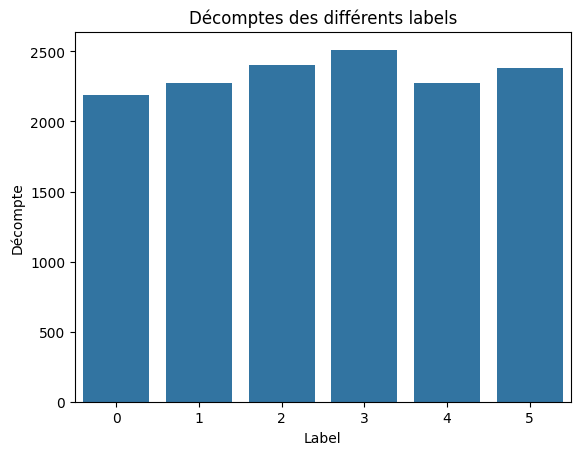

In [6]:
print(f"Forme des images : {images.shape}")
print(f"Forme des labels : {labels.shape}")

seaborn.countplot(x=labels.numpy())
plt.title("Décomptes des différents labels")
plt.ylabel("Décompte")
plt.xlabel("Label")
plt.show()

In [7]:
# Création de la grille de sous-plots. On donne l'argument figsize pour agrandir
# la taille de la figure qui est petite par défaut
f, ax = plt.subplots(5, 5, figsize=(15, 15))

# On choisit 25 indices au hasard, sans replacement (on ne veut pas afficher la
# même image deux fois)
random_indexes = numpy.random.choice(images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    image = images[img_index]
    label = label_names[labels[img_index]]

    # Affichage avec matplotlib et sa fonction imshow, très pratique en vision par
    # ordinateur
    ax[i, j].imshow(image)
    ax[i, j].set_title(f"Exemple {img_index} ({label})")
    ax[i, j].axis('off')

Output hidden; open in https://colab.research.google.com to view.

## Création du modèle

Voici un exemple de CNN « minimaliste »

In [8]:
# Initialisation et définition du modéle

# Le modèle est un empilement de couches où le flux de données est séquentiel
simple_cnn = keras.models.Sequential(name="simple_cnn")
simple_cnn.add(keras.layers.Input(shape=INPUT_SHAPE))
# Une première couche de 1 convolutions de 3x3 pixels
simple_cnn.add(keras.layers.Conv2D(1, kernel_size=(3, 3), activation="relu"))
# Une couche de max pooling
simple_cnn.add(keras.layers.MaxPool2D(3,3))

# Une couche de manipulation des tenseurs : suppression de toutes les dimensions
# sauf celle de batch et une autre qui contient toutes les valeurs
simple_cnn.add(keras.layers.Flatten())

# Une couche de sortie dense avec 6 neurones et un softmax comme activation
simple_cnn.add(keras.layers.Dense(6, activation="softmax"))

# Compilation du modèle avec la définition de la fonction de perte
simple_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                   loss="sparse_categorical_crossentropy",
                   metrics=["accuracy"])

# Affichage d'un résumé du modèle
simple_cnn.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 1)    │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2401)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        14,412 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,440 (56.41 KB)

 Trainable params: 14,440 (56.41 KB)

 Non-trainable params: 0 (0.00 B)

## Explication des différents nombres de paramètres

Premier layer de 1 convolutions : taille du kernel × nb kernel × nb canaux en entrée + nb biais (= nb kernel) = 3 × 3 × 1 × 3 + 1 = 28

Dernier layer dense : input dim × output dim + nb biais = 2401 × 6 + 6

## Apprentissage

Apprenons ce modèle sur nos données ! Dans un premier temps, nous entraînons sur une seule epoch pour simplement vérifier que notre modèle est opérationnel.

In [9]:
# Apprentissage du modèle
simple_cnn.fit(images, labels, epochs=1, validation_split=0.30)

307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.2456 - loss: 9.3706 - val_accuracy: 0.2750 - val_loss: 6.0033


## Améliorons cette performance

In [10]:
CONV_LAYERS_NUMBER = 6
DENSE_LAYERS_SIZES = (200, 100, 50)


def conv() -> keras.layers.Conv2D:
  return keras.layers.Conv2D(filters=200,
                             kernel_size=(3,3),
                             activation="relu",
                             kernel_initializer="orthogonal",
                             padding="same")


def dense(size: int, activation: str = "relu") -> keras.layers.Dense:
  return keras.layers.Dense(size,
                            activation=activation,
                            kernel_initializer="orthogonal")


def dropout() -> keras.layers.Dropout:
  return keras.layers.Dropout(rate=0.2)


def max_pooling() -> keras.layers.MaxPooling2D:
  return keras.layers.MaxPooling2D(pool_size=(2, 2),
                                   strides=(2, 2),
                                   padding="same")


deep_cnn = keras.Sequential(name="deep_cnn")
deep_cnn.add(keras.layers.Input(shape=INPUT_SHAPE))

for _ in range(CONV_LAYERS_NUMBER - 1):
  deep_cnn.add(conv())
  deep_cnn.add(max_pooling())
deep_cnn.add(conv())

deep_cnn.add(keras.layers.Flatten())

for size in DENSE_LAYERS_SIZES:
  deep_cnn.add(dropout())
  deep_cnn.add(dense(size))

deep_cnn.add(dropout())
deep_cnn.add(dense(6, "softmax"))

deep_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

# Affichage d'un résumé du modèle
deep_cnn.summary()

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 150, 150, 200)  │         5,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 75, 75, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 75, 75, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 38, 38, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 38, 38, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 19, 19, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 19, 19, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 200)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 200)    │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 200)      │       360,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │     1,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,832,256 (10.80 MB)

 Trainable params: 2,832,256 (10.80 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Visualisation des métriques d'entrainement
def plot_metrics(history) -> None:
  plt.plot(training.history["accuracy"])
  plt.plot(training.history["val_accuracy"])
  plt.title("Accuracy du modèle")
  plt.ylabel("Accuracy")
  plt.xlabel("Epoch")
  plt.legend(["Entraînement", "Validation"], loc="upper left")
  plt.show()

  plt.plot(training.history["loss"])
  plt.plot(training.history["val_loss"])
  plt.title("Perte du modèle")
  plt.ylabel("Perte")
  plt.xlabel("Epoch")
  plt.legend(["Entraînement", "Validation"], loc="upper right")
  plt.show()

Epoch 1/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.3325 - loss: 1.6873 - val_accuracy: 0.5590 - val_loss: 1.1707
Epoch 2/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 59s 771ms/step - accuracy: 0.5194 - loss: 1.2085 - val_accuracy: 0.6117 - val_loss: 0.9888
Epoch 3/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 59s 769ms/step - accuracy: 0.5794 - loss: 1.0804 - val_accuracy: 0.6545 - val_loss: 0.9035
Epoch 4/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 59s 768ms/step - accuracy: 0.6319 - loss: 0.9663 - val_accuracy: 0.7034 - val_loss: 0.7954
Epoch 5/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 59s 768ms/step - accuracy: 0.6648 - loss: 0.8916 - val_accuracy: 0.7058 - val_loss: 0.7953
Epoch 6/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 59s 768ms/step - accuracy: 0.7031 - loss: 0.8128 - val_accuracy: 0.7108 - val_loss: 0.7947
Epoch 7/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 59s 770ms/step - accuracy: 0.7235 - loss: 0.7635 - val_accuracy: 0.7654 - val_loss: 0.6686
Epoch 8/15
77/77 ━━━━━━━━━━━━━━━━━━━━ 59s 771ms/step - accuracy: 0.7487 - loss: 0.7094 - val_accura

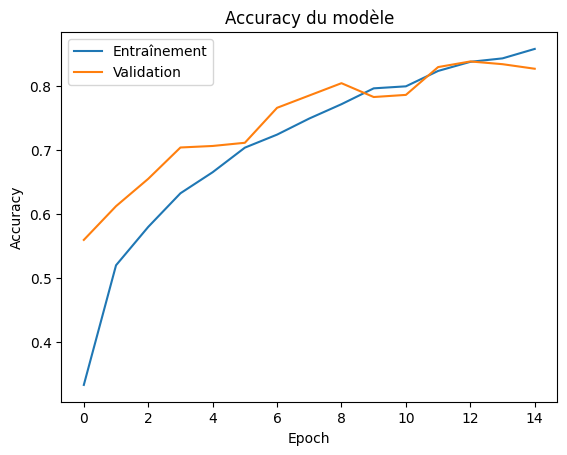

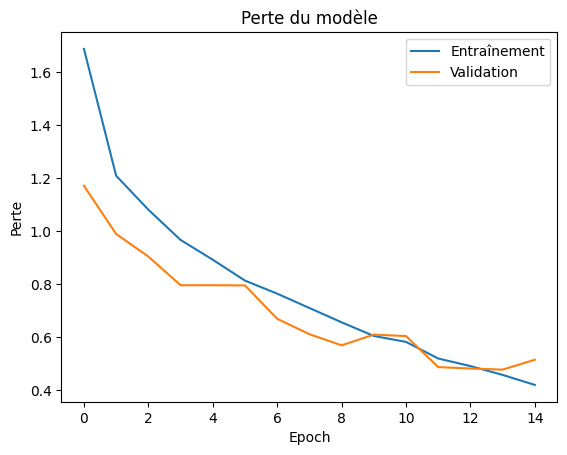

In [12]:
# Apprentissage du modèle

BEST_DEEP_MODEL_PATH = "best_deep_model.weights.h5"

early_stopping = keras.callbacks.EarlyStopping(
    patience=5,
    monitor="val_loss")

model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath=BEST_DEEP_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_weights_only=True,
    save_best_only=True)

training = deep_cnn.fit(images,
                        labels,
                        epochs=15,
                        validation_split=0.30,
                        batch_size=128,
                        callbacks=[early_stopping, model_checkpoint])

deep_cnn.load_weights(BEST_DEEP_MODEL_PATH)

plot_metrics(training.history)

## Évaluation des performances sur l'ensemble de test

Dans le dossier `seg_test` se trouve un ensemble de données qui n'ont jamais été vues durant l'apprentissage.

On utilisera la méthode `evaluate(X, y)` du modèle pour évaluer la qualité de nos prédictions sur ce dataset.

In [ ]:
test_images,test_labels = get_images(
    pathlib.Path("dataset-landscape") / "seg_test")
loss, accuracy = deep_cnn.evaluate(test_images, test_labels, verbose=False)
print(f"Loss: {loss:.2f}, accuracy: {accuracy:.2f}")

Traitement des dossiers:   0%|          | 0/6 [00:00<?, ?it/s]

Dossier glacier:   0%|          | 0/553 [00:00<?, ?it/s]

Dossier mountain:   0%|          | 0/525 [00:00<?, ?it/s]

Dossier forest:   0%|          | 0/474 [00:00<?, ?it/s]

Dossier street:   0%|          | 0/501 [00:00<?, ?it/s]

Dossier buildings:   0%|          | 0/437 [00:00<?, ?it/s]

Dossier sea:   0%|          | 0/510 [00:00<?, ?it/s]

## Analyse d'erreur

On affiche la matrice de confusion puis on regarde des images mal classées.

In [ ]:
def predict(model: keras.Model, images: tf.Tensor) -> tf.Tensor:
  return tf.math.argmax(model.predict(images), axis=-1)


def analyze_preds(preds: tf.Tensor, labels: tf.Tensor) -> None:
  confusion_matrix = sklearn.metrics.confusion_matrix(preds, labels)
  seaborn.heatmap(confusion_matrix,
                  cmap="rocket_r",
                  xticklabels=label_names,
                  yticklabels=label_names,
                  annot=True,
                  fmt="d")
  plt.title("Matrice de confusion")
  plt.show()

  seaborn.countplot(x=[label_names[x] for x in preds])
  plt.title("Décomptes des classes prédites")
  plt.ylabel("Décompte")
  plt.xlabel("Class")
  plt.show()

In [ ]:
test_preds = predict(deep_cnn, test_images)
analyze_preds(test_preds, test_labels)

In [ ]:
def plot_mistakes(predicted_class: str,
                  true_class: str,
                  images: tf.Tensor,
                  preds: tf.Tensor,
                  labels: tf.Tensor
                  ) -> None:
  print(f"Prédiction : {predicted_class}, classe réelle : {true_class}")
  mistakes = images[(preds == label_to_index[predicted_class])
                         & (labels == label_to_index[true_class])]
  random_indexes = numpy.random.choice(mistakes.shape[0],
                                       size=min(mistakes.shape[0], 25),
                                       replace=False)
  grid_indexes = itertools.product(range(5), repeat=2)

  if mistakes.shape[1] == 3:
    mistakes = tf.transpose(mistakes, perm=(0, 2, 3, 1))

  _, ax = plt.subplots(5, 5, figsize=(15, 15))
  for img_index, (i, j) in zip(random_indexes, grid_indexes):
    ax[i, j].imshow(mistakes[img_index])
    ax[i, j].axis("off")
  plt.show()

In [ ]:
# Plot les images prédites glacier alors qu'elles ont un label montagne
plot_mistakes("glacier", "mountain", test_images, test_preds, test_labels)

In [18]:
# Plot les images prédites glacier alors qu'elles ont un label mer
plot_mistakes("glacier", "sea", test_images, test_preds, test_labels)

Output hidden; open in https://colab.research.google.com to view.

Prédiction : buildings, classe réelle : sea


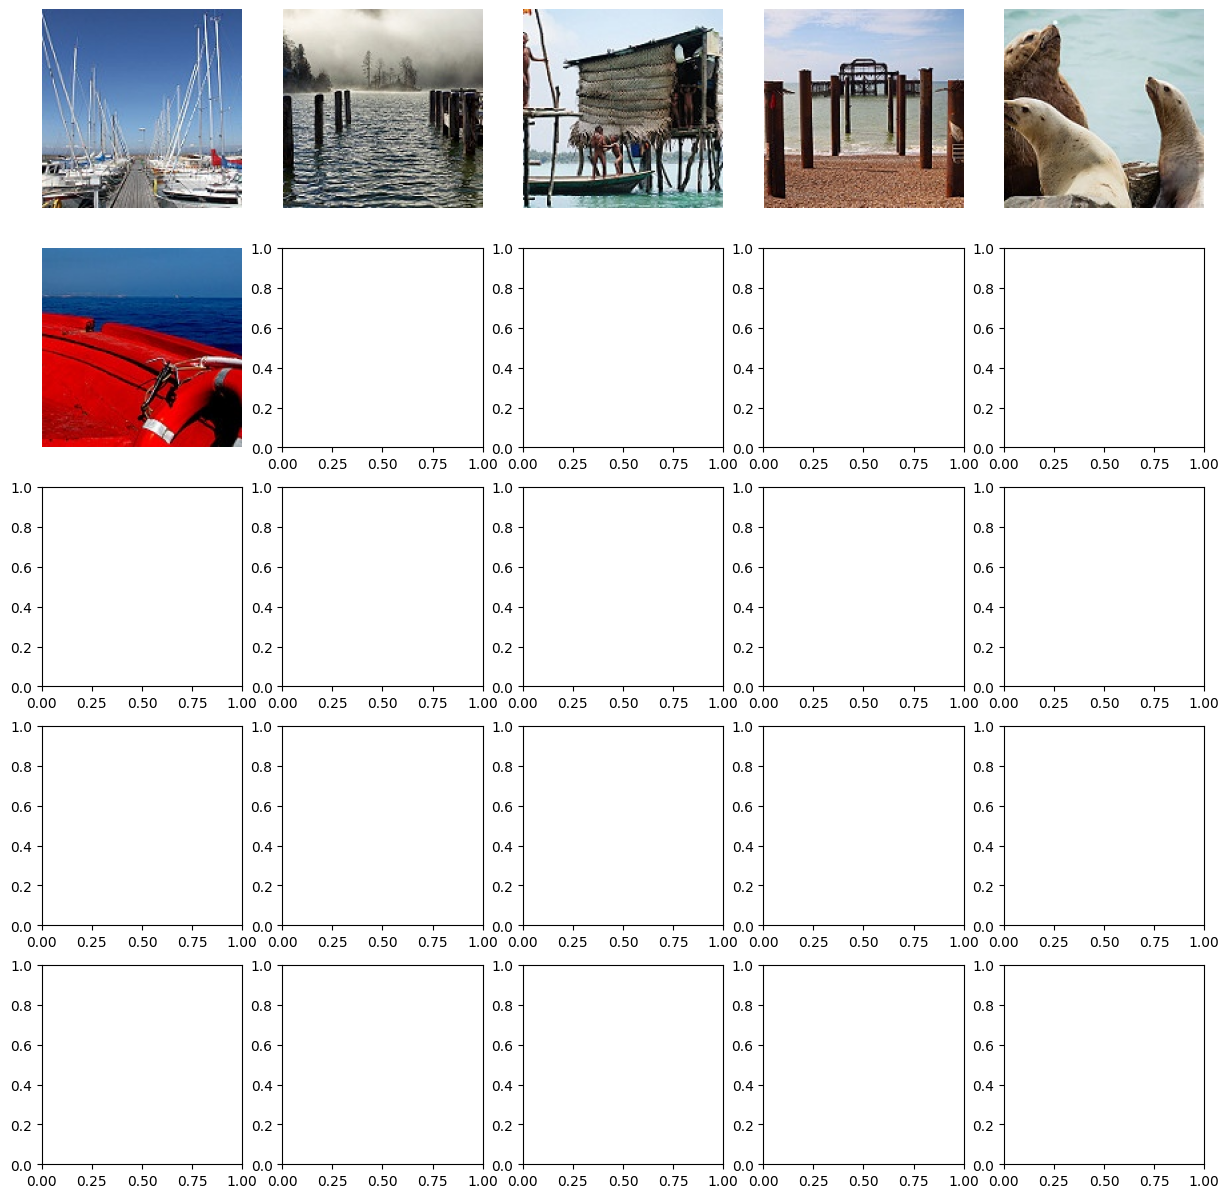

In [19]:
# Plot les images prédites bâtiment alors qu'elles ont un label mer
plot_mistakes("buildings", "sea", test_images, test_preds, test_labels)

In [20]:
def evaluate(model: keras.Model, images: tf.Tensor, labels: tf.Tensor) -> None:
  loss, accuracy = model.evaluate(images, labels, verbose=False)
  print(f"Loss: {loss:.2f}, accuracy: {accuracy:.2f}")
  preds = predict(model, images)
  analyze_preds(preds, labels)
  plot_mistakes("glacier", "mountain", images, preds, labels)
  plot_mistakes("glacier", "sea", images, preds, labels)
  plot_mistakes("buildings", "sea", images, preds, labels)

In [21]:
evaluate(deep_cnn, test_images, test_labels)

Output hidden; open in https://colab.research.google.com to view.

## Transfert d'apprentissage

In [22]:
base_model = keras.applications.EfficientNetV2B0(include_top=False,
                                                 weights="imagenet",
                                                 input_shape=(150, 150, 3))

base_model.trainable = False

transferred_cnn = keras.Sequential(
    [base_model,
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(1024, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(256, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(64, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Conv2D(16, 1, activation="relu"),
     keras.layers.SpatialDropout2D(0.1),
     keras.layers.Flatten(),
     keras.layers.Dense(6, activation="softmax", kernel_regularizer="l2")],
    name="transferred_cnn")

transferred_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
                        loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

transferred_cnn.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "transferred_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 5, 5, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 5, 5, 1280)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 5, 1024)     │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 5, 5, 1024)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 5, 5, 256)      │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 5, 5, 256)      │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 5, 5, 64)       │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 5, 5, 64)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 5, 5, 16)       │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 5, 5, 16)       │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         2,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,513,350 (28.66 MB)

 Trainable params: 1,594,038 (6.08 MB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [23]:
training = transferred_cnn.fit(images,
                               labels,
                               epochs=5,
                               validation_split=0.30,
                               batch_size=512)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.4309 - loss: 1.6119 - val_accuracy: 0.7409 - val_loss: 1.0644
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 362ms/step - accuracy: 0.7104 - loss: 0.9705 - val_accuracy: 0.8502 - val_loss: 0.6164
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 371ms/step - accuracy: 0.8089 - loss: 0.6749 - val_accuracy: 0.8813 - val_loss: 0.4756
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 370ms/step - accuracy: 0.8458 - loss: 0.5525 - val_accuracy: 0.8962 - val_loss: 0.4207
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 361ms/step - accuracy: 0.8689 - loss: 0.4884 - val_accuracy: 0.9045 - val_loss: 0.3923


In [ ]:
evaluate(transferred_cnn, test_images, test_labels)

## Avec les transformeurs pour la vision par ordinateur (ViT)

In [ ]:
!pip install 'transformers < 5'

In [ ]:
images, labels = get_images(pathlib.Path("dataset-landscape") / "seg_train",
                            size=224,
                            channels_first=True)

In [ ]:
import transformers


vit = transformers.TFAutoModel.from_pretrained(
    "google/vit-base-patch16-224-in21k", use_safetensors=False)

In [ ]:
import transformers


vit = transformers.TFAutoModel.from_pretrained(
    "google/vit-base-patch16-224-in21k", use_safetensors=False)

vit.trainable = False
inputs = keras.layers.Input((3, 224, 224))
x = keras.layers.Lambda(lambda t: t / 255)(inputs)
x = keras.layers.Normalization(mean=0.5, variance=0.5 ** 2)(x)

# Wrap the vit model call in a Lambda layer to handle the tensor type issue
x = keras.layers.Lambda(lambda x: vit(x).last_hidden_state)(x)

x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dense(64, activation="relu")(x)
x = keras.layers.Dense(32, activation="relu")(x)
x = keras.layers.Flatten()(x)
outputs = keras.layers.Dense(6, activation="softmax")(x)
transferred_transformer = keras.Model(inputs=inputs,
                                      outputs=outputs,
                                      name="transferred_transformer")
transferred_transformer.compile(optimizer="adam",
                                metrics=["accuracy"],
                                loss="sparse_categorical_crossentropy")
transferred_transformer.summary()

In [29]:
transferred_transformer.fit(images, labels, epochs=3, validation_split=0.3, batch_size=512)

Epoch 1/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 210s 9s/step - accuracy: 0.8170 - loss: 0.5990 - val_accuracy: 0.9250 - val_loss: 0.2335
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 150s 8s/step - accuracy: 0.9395 - loss: 0.1834 - val_accuracy: 0.9354 - val_loss: 0.2019
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 151s 8s/step - accuracy: 0.9528 - loss: 0.1328 - val_accuracy: 0.9375 - val_loss: 0.1833


In [ ]:
test_images, test_labels = get_images(
    pathlib.Path("dataset-landscape") / "seg_test",
    size=224,
    channels_first=True)
evaluate(transferred_transformer, test_images, test_labels)

## Prédire dans des condition « réelles »

Dans le dossier `seg_pred` se trouvent des images non-annotées. On ne peut donc pas évaluer correctement les performances sur cet ensemble.

Cependant, on peut afficher des photos et les probabilités que notre modèle attribue à chaque classe.

In [ ]:
pred_images = get_images(
    pathlib.Path("dataset-landscape") / "seg_pred",
    size=224,
    channels_first=True,
    create_labels=False)

In [ ]:
# Création de la grille de sous-plots. On donne l'argument figsize pour agrandir
# la taille de la figure qui est petite par défaut
_, ax = plt.subplots(10, 5, figsize=(30, 45))

# On choisit 25 indices au hasard, sans replacement (on ne veut pas afficher la
# même image deux fois)
random_indexes = numpy.random.choice(pred_images.shape[0],
                                     size=(5, 5),
                                     replace=False)

for i in range(5):
  for j in range(5):
    img_index = random_indexes[i, j]
    # Récupération de l'image et prédiction de sa classe
    image = pred_images[img_index]
    probabilities = transferred_transformer.predict(image[None, ...])[0]
    predicted_class = label_names[numpy.argmax(probabilities)]

    # Affichage avec matplotlib et sa fonction imshow, très pratique en vision
    # par ordinateur
    ax[i * 2, j].imshow(tf.transpose(image, perm=(1, 2, 0)))
    ax[i * 2, j].set_title(f"Exemple {img_index}")
    ax[i * 2, j].axis('off')

    # Affichage de la distribution de prédiction sur la ligne d'en dessous
    ax[i * 2 + 1, j].bar(label_names, probabilities)

## Analyse par occlusion

In [ ]:
images, labels = get_images(pathlib.Path("dataset-landscape") / "seg_train")

Classe réelle : sea
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Proba de la bonne classe avec l'image complète : 0.9853935


  0%|          | 0/169 [00:00<?, ?it/s]

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 514ms/step


/tmp/ipykernel_2679/3134870610.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = matplotlib.cm.get_cmap("jet")


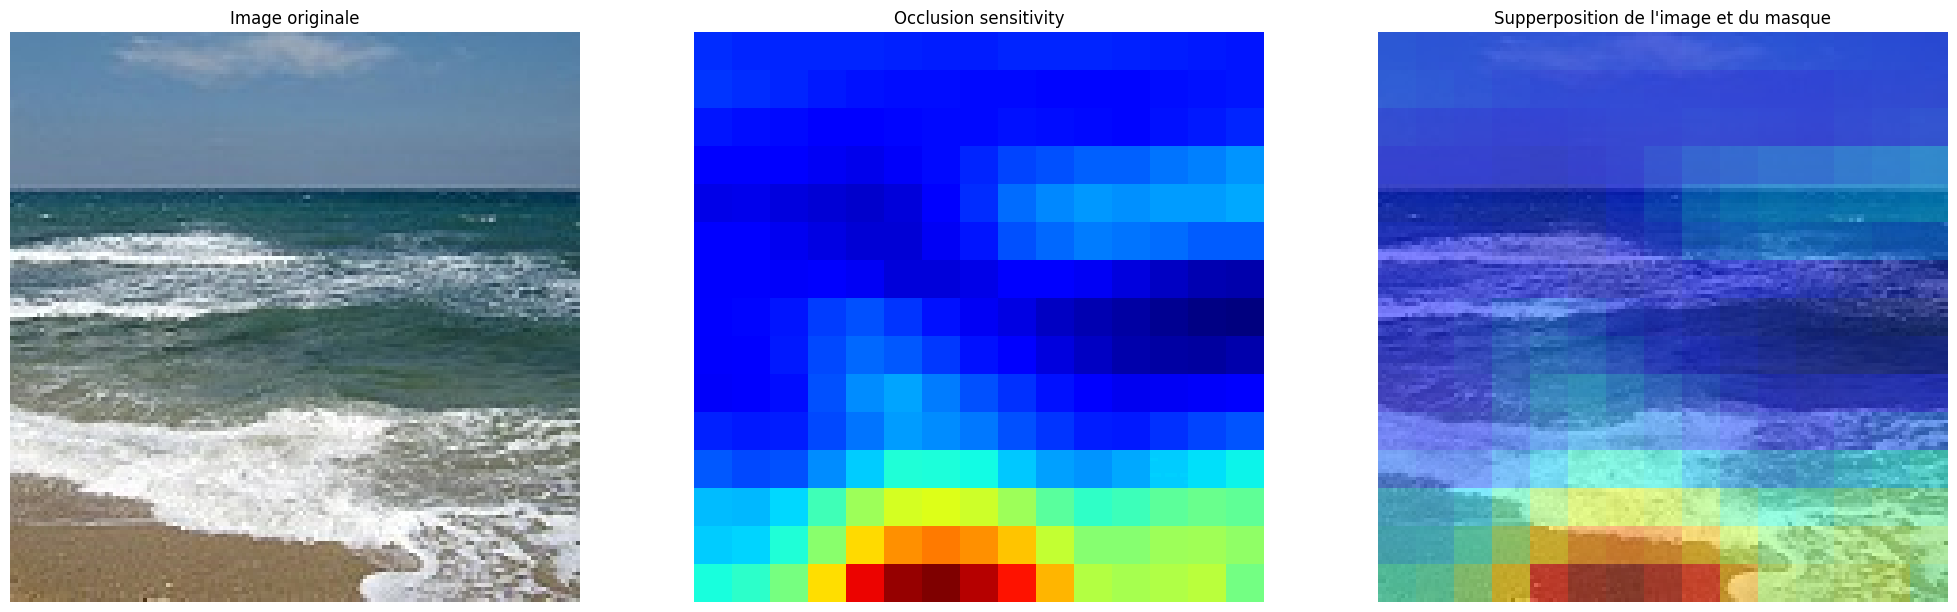

In [34]:
def occlusion_analysis(image: tf.Tensor,
                       label: int,
                       size: int = 30,
                       step: int = 10
                       ) -> None:
  print("Classe réelle :", label_names[label])
  label_prob_full = deep_cnn.predict(image[None, ...])[0, label]
  print("Proba de la bonne classe avec l'image complète :",
        label_prob_full)
  height, width = image.shape[:2]
  n_height = image.shape[0] - size + 1
  n_width = image.shape[1] - size + 1
  occluded_images = []
  mask = tf.cast(tf.fill(image.shape, 127), tf.uint8)
  ones = tf.ones(size, dtype="uint8")
  ii = list(range(0, n_height, step))
  jj = list(range(0, n_width, step))
  for i, j in tqdm.notebook.tqdm(list(itertools.product(ii, jj)), leave=False):
    indices_height = tf.pad(ones, [[i, height - size - i]])
    indices_width = tf.pad(ones, [[j, width - size - j]])
    indices = (indices_height[:, None] * indices_width[None, :])[..., None]
    occluded_images.append(tf.where(tf.cast(indices, tf.bool), mask, image))
  weights = tf.nn.conv2d_transpose(tf.ones((1, len(ii), len(jj), 1)),
                                   tf.ones((size, size, 1, 1)),
                                   (1, *image.shape[:2], 1),
                                   step,
                                   padding="VALID")
  occluded_images_tensor = tf.stack(occluded_images)
  preds = deep_cnn.predict(occluded_images_tensor).reshape(len(ii), len(jj), -1)
  label_preds = preds[None, ..., label, None]
  heatmap = tf.nn.conv2d_transpose(label_preds,
                                   tf.ones((size, size, 1, 1)),
                                   (1, *image.shape[:2], 1),
                                   step,
                                   padding="VALID")
  heatmap /= weights
  heatmap *= -1
  heatmap -= numpy.min(heatmap)
  heatmap /= numpy.max(heatmap)
  heatmap *= 255

  heatmap = numpy.array(heatmap).astype(numpy.uint8)[0,:,:,:]
  # Use jet colormap to colorize heatmap
  jet = matplotlib.cm.get_cmap("jet")

  # Use RGB values of the colormap
  jet_colors = jet(numpy.arange(256))[:, :3]
  jet_heatmap = jet_colors[heatmap][:,:,0,:]
  # Create an image with RGB colorized heatmap
  jet_heatmap = skimage.transform.resize(jet_heatmap, (image.shape[0], image.shape[1]))


  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 8))
  ax1.imshow(image)
  ax1.axis("off")
  ax1.set_title("Image originale")
  ax2.imshow(jet_heatmap)
  ax2.axis("off")
  ax2.set_title("Occlusion sensitivity")
  #ax3.imshow(superimposed_img)
  ax3.imshow(image)
  ax3.imshow(jet_heatmap, alpha = 0.5)
  ax3.axis("off")
  ax3.set_title("Supperposition de l'image et du masque")
  fig.show()


i = 600
occlusion_analysis(images[i], labels[i])